# Benchmark : SHAP standard vs FastTreeExplainer (MLX / C++)

## California Housing - 20 640 points - XGBoost

Ce notebook compare les performances de calcul des valeurs de Shapley :
- **Ordre 1** : valeurs SHAP individuelles
- **Ordre 2** : interactions SHAP (matrice M x M par sample)

Entre la librairie **SHAP standard** et notre implementation **FastTreeExplainer**
optimisee pour Apple Silicon (MLX GPU + C++ multi-thread).

Enfin, les valeurs SHAP pre-calculees sont injectees dans le **GUI AntakIA**
pour tester la tenue en charge sur l'integralite du jeu de donnees.

In [1]:
import os, sys, time, warnings
warnings.filterwarnings('ignore')

# Paths pour les modules locaux
sys.path.insert(0, '../src')                # AntakIA
sys.path.insert(0, '../../treerank')        # tree_shap package

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# SHAP standard
import shap
print(f"SHAP version {shap.__version__}")

# XGBoost
from xgboost import XGBRegressor
import xgboost
print(f"XGBoost version {xgboost.__version__}")

# FastTreeExplainer (optionnel)
try:
    from tree_shap import FastTreeExplainer
    FAST_AVAILABLE = True
    print("FastTreeExplainer disponible")
except ImportError as e:
    FAST_AVAILABLE = False
    print(f"FastTreeExplainer non disponible: {e}")
    print("  -> Seul SHAP standard sera utilise")

SHAP version 0.50.0
XGBoost version 3.1.2
FastTreeExplainer disponible


In [2]:
# Chargement du dataset COMPLET (20 640 points)
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='MedHouseVal')

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

FEATURE_ALIASES = {
    "MedInc": "Revenu median",
    "HouseAge": "Age du logement",
    "AveRooms": "Nb moyen de pieces",
    "AveBedrms": "Nb moyen de chambres",
    "Population": "Population quartier",
    "AveOccup": "Occupation moyenne",
    "Latitude": "Latitude",
    "Longitude": "Longitude"
}

print(f"Dataset complet : {len(X)} points, {X.shape[1]} features")
print(f"Train : {len(X_train)} points")
print(f"Test  : {len(X_test)} points")

Dataset complet : 20640 points, 8 features
Train : 16512 points
Test  : 4128 points


In [3]:
# XGBoost avec parametres par defaut
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

r2_train = model.score(X_train, y_train)
r2_test = model.score(X_test, y_test)
print(f"XGBoost entraine :")
print(f"  R2 train       = {r2_train:.4f}")
print(f"  R2 test        = {r2_test:.4f}")
print(f"  n_estimators   = {model.n_estimators}")
print(f"  max_depth      = {model.max_depth}")

XGBoost entraine :
  R2 train       = 0.9446
  R2 test        = 0.8301
  n_estimators   = None
  max_depth      = None


## 1. Comparaison Ordre 1 : Valeurs SHAP

Calcul des valeurs SHAP d'ordre 1 sur **l'integralite du jeu d'entrainement**
avec les deux methodes.

In [4]:
# --- SHAP standard - Ordre 1 ---
print("=" * 60)
print("SHAP standard - Ordre 1")
print("=" * 60)

t0 = time.time()
explainer_std = shap.TreeExplainer(model)
sv_shap = explainer_std.shap_values(X_train)
t_shap_o1 = time.time() - t0

base_value_shap = float(np.asarray(explainer_std.expected_value).flat[0])

print(f"Temps         : {t_shap_o1:.3f}s")
print(f"Shape         : {sv_shap.shape}")
print(f"Base value    : {base_value_shap:.6f}")

# Verification additivite
y_pred = model.predict(X_train)
reconstructed = sv_shap.sum(axis=1) + base_value_shap
add_err = np.max(np.abs(y_pred - reconstructed))
print(f"Additivite    : max|f(x) - (base + sum phi)| = {add_err:.2e}")

SHAP standard - Ordre 1
Temps         : 1.531s
Shape         : (16512, 8)
Base value    : 2.071889
Additivite    : max|f(x) - (base + sum phi)| = 4.77e-06


In [5]:
# --- FastTreeExplainer - Ordre 1 ---
if FAST_AVAILABLE:
    print("=" * 60)
    print("FastTreeExplainer - Ordre 1")
    print("=" * 60)

    t0 = time.time()
    fast_exp = FastTreeExplainer(model)
    t_init = time.time() - t0
    print(f"Init          : {t_init:.3f}s")

    t0 = time.time()
    sv_fast = fast_exp.shap_values(X_train)
    t_fast_o1 = time.time() - t0

    base_value_fast = float(fast_exp.base_value)

    print(f"Temps calcul  : {t_fast_o1:.3f}s")
    print(f"Shape         : {sv_fast.shape}")
    print(f"Base value    : {base_value_fast:.6f}")

    # Verification additivite
    reconstructed_fast = sv_fast.sum(axis=1) + base_value_fast
    add_err_fast = np.max(np.abs(y_pred - reconstructed_fast))
    print(f"Additivite    : max|f(x) - (base + sum phi)| = {add_err_fast:.2e}")
else:
    print("FastTreeExplainer non disponible - comparaison impossible")
    t_fast_o1 = None
    sv_fast = None

FastTreeExplainer - Ordre 1
FastTreeExplainer: Apple M2 Max, 100 trees (depth≤6), 8 features, backends=[C++(12CPU)], init=1.73s
Init          : 2.298s
Shapley_values [CPP]: 16512 samples x 100 trees -> 2.395s
Temps calcul  : 2.396s
Shape         : (16512, 8)
Base value    : 2.071889
Additivite    : max|f(x) - (base + sum phi)| = 4.48e-06


In [6]:
# --- Comparaison Ordre 1 ---
if FAST_AVAILABLE and sv_fast is not None:
    print("=" * 60)
    print("Comparaison Ordre 1")
    print("=" * 60)

    max_err_o1 = np.max(np.abs(sv_shap - sv_fast))
    mean_err_o1 = np.mean(np.abs(sv_shap - sv_fast))
    ss_res = np.sum((sv_shap.ravel() - sv_fast.ravel())**2)
    ss_tot = np.sum((sv_shap.ravel() - np.mean(sv_shap.ravel()))**2)
    r2_o1 = 1 - ss_res / ss_tot
    speedup_o1 = t_shap_o1 / t_fast_o1

    print(f"Max erreur abs. : {max_err_o1:.2e}")
    print(f"Erreur moyenne  : {mean_err_o1:.2e}")
    print(f"R2 correlation  : {r2_o1:.10f}")
    print()
    print(f"SHAP standard       : {t_shap_o1:.3f}s")
    print(f"FastTreeExplainer   : {t_fast_o1:.3f}s")
    print(f"Speedup             : {speedup_o1:.1f}x")
else:
    max_err_o1 = None
    speedup_o1 = None

Comparaison Ordre 1
Max erreur abs. : 1.97e-06
Erreur moyenne  : 4.65e-08
R2 correlation  : 1.0000000000

SHAP standard       : 1.531s
FastTreeExplainer   : 2.396s
Speedup             : 0.6x


## 2. Comparaison Ordre 2 : Interactions SHAP

Les interactions d'ordre 2 sont beaucoup plus couteuses : O(N * L * D^3).
On utilise un sous-ensemble pour la comparaison.

Ajuster `N_INTER` selon la patience et la puissance de la machine.

In [7]:
# Nombre de samples pour la comparaison interactions
N_INTER = 500
X_inter = X_train.iloc[:N_INTER]

# --- SHAP standard - Ordre 2 ---
print("=" * 60)
print(f"SHAP standard - Ordre 2 (interactions) - {N_INTER} samples")
print("=" * 60)

t0 = time.time()
iv_shap = explainer_std.shap_interaction_values(X_inter)
t_shap_o2 = time.time() - t0

print(f"Temps         : {t_shap_o2:.3f}s")
print(f"Shape         : {iv_shap.shape}")

SHAP standard - Ordre 2 (interactions) - 500 samples
Temps         : 0.634s
Shape         : (500, 8, 8)


In [8]:
# --- FastTreeExplainer - Ordre 2 ---
if FAST_AVAILABLE:
    print("=" * 60)
    print(f"FastTreeExplainer - Ordre 2 (interactions) - {N_INTER} samples")
    print("=" * 60)

    t0 = time.time()
    iv_fast = fast_exp.shap_interaction_values(X_inter)
    t_fast_o2 = time.time() - t0

    print(f"Temps         : {t_fast_o2:.3f}s")
    print(f"Shape         : {iv_fast.shape}")
else:
    print("FastTreeExplainer non disponible")
    iv_fast = None
    t_fast_o2 = None

FastTreeExplainer - Ordre 2 (interactions) - 500 samples
Shapley_interaction_values [CPP]: 500 samples x 100 trees -> 0.236s
Temps         : 0.238s
Shape         : (500, 8, 8)


In [9]:
# --- Comparaison Ordre 2 ---
if FAST_AVAILABLE and iv_fast is not None:
    print("=" * 60)
    print("Comparaison Ordre 2")
    print("=" * 60)

    max_err_o2 = np.max(np.abs(iv_shap - iv_fast))
    mean_err_o2 = np.mean(np.abs(iv_shap - iv_fast))
    ss_res2 = np.sum((iv_shap.ravel() - iv_fast.ravel())**2)
    ss_tot2 = np.sum((iv_shap.ravel() - np.mean(iv_shap.ravel()))**2)
    r2_o2 = 1 - ss_res2 / ss_tot2
    speedup_o2 = t_shap_o2 / t_fast_o2

    print(f"Max erreur abs. : {max_err_o2:.2e}")
    print(f"Erreur moyenne  : {mean_err_o2:.2e}")
    print(f"R2 correlation  : {r2_o2:.10f}")
    print()
    print(f"SHAP standard       : {t_shap_o2:.3f}s")
    print(f"FastTreeExplainer   : {t_fast_o2:.3f}s")
    print(f"Speedup             : {speedup_o2:.1f}x")
else:
    max_err_o2 = None
    speedup_o2 = None

Comparaison Ordre 2
Max erreur abs. : 1.40e-06
Erreur moyenne  : 4.58e-08
R2 correlation  : 1.0000000000

SHAP standard       : 0.634s
FastTreeExplainer   : 0.238s
Speedup             : 2.7x


In [10]:
# --- Tableau recapitulatif ---
print("=" * 70)
print("TABLEAU RECAPITULATIF")
print("=" * 70)

rows = []
rows.append({
    'Calcul': f'Ordre 1 ({len(X_train)} pts)',
    'SHAP std (s)': f'{t_shap_o1:.3f}',
    'FastTree (s)': f'{t_fast_o1:.3f}' if t_fast_o1 else 'N/A',
    'Speedup': f'{speedup_o1:.1f}x' if speedup_o1 else 'N/A',
    'Max err': f'{max_err_o1:.2e}' if max_err_o1 is not None else 'N/A',
})
rows.append({
    'Calcul': f'Ordre 2 ({N_INTER} pts)',
    'SHAP std (s)': f'{t_shap_o2:.3f}',
    'FastTree (s)': f'{t_fast_o2:.3f}' if t_fast_o2 else 'N/A',
    'Speedup': f'{speedup_o2:.1f}x' if speedup_o2 else 'N/A',
    'Max err': f'{max_err_o2:.2e}' if max_err_o2 is not None else 'N/A',
})

summary_df = pd.DataFrame(rows)
print()
print(summary_df.to_string(index=False))

TABLEAU RECAPITULATIF

             Calcul SHAP std (s) FastTree (s) Speedup  Max err
Ordre 1 (16512 pts)        1.531        2.396    0.6x 1.97e-06
  Ordre 2 (500 pts)        0.634        0.238    2.7x 1.40e-06


## 3. Visualisations SHAP

Visualisations basees sur les valeurs SHAP calculees (FastTreeExplainer si disponible,
sinon SHAP standard).

Visualisations basees sur : FastTreeExplainer


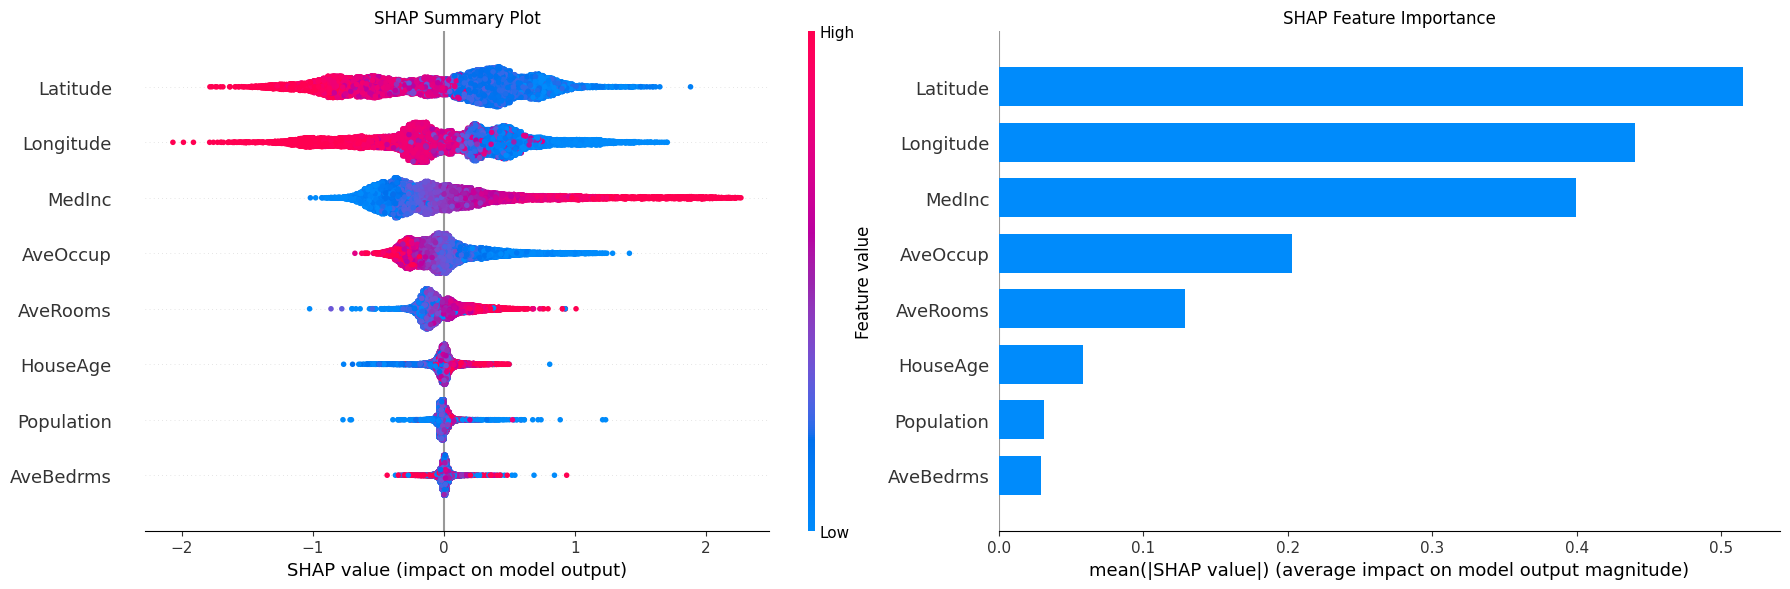

In [11]:
# Choisir les SHAP values a afficher
sv_display = sv_fast if (FAST_AVAILABLE and sv_fast is not None) else sv_shap
source_name = "FastTreeExplainer" if (FAST_AVAILABLE and sv_fast is not None) else "SHAP standard"
print(f"Visualisations basees sur : {source_name}")

# Summary plot + Bar plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(sv_display, X_train, show=False, plot_size=None)
axes[0].set_title("SHAP Summary Plot")

plt.sca(axes[1])
shap.summary_plot(sv_display, X_train, plot_type="bar", show=False, plot_size=None)
axes[1].set_title("SHAP Feature Importance")

plt.tight_layout()
plt.show()

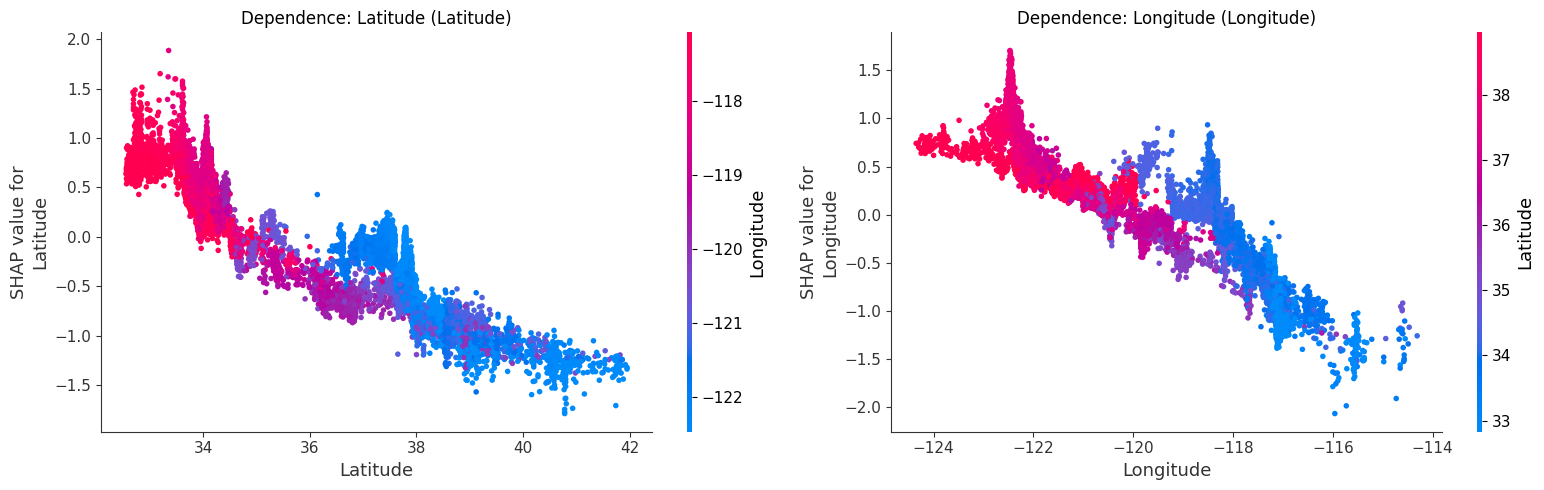

In [12]:
# Dependence plots pour les 2 features les plus importantes
importances = np.abs(sv_display).mean(axis=0)
top_feats = np.argsort(importances)[::-1][:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, feat_idx in enumerate(top_feats):
    feat_name = X_train.columns[feat_idx]
    alias = FEATURE_ALIASES.get(feat_name, feat_name)
    shap.dependence_plot(feat_name, sv_display, X_train, show=False, ax=axes[i])
    axes[i].set_title(f"Dependence: {feat_name} ({alias})")

plt.tight_layout()
plt.show()

## 4. Integration AntakIA

Injection des valeurs SHAP pre-calculees dans AntakIA pour tester
la tenue en charge du GUI sur l'integralite du jeu d'entrainement
(~16 500 points avec 8 features).

In [13]:
# Preparer les SHAP values au format AntakIA
# X_exp : DataFrame avec memes colonnes et meme index que X_train
sv_for_atk = sv_fast if (FAST_AVAILABLE and sv_fast is not None) else sv_shap

shap_df = pd.DataFrame(
    sv_for_atk,
    columns=X_train.columns,
    index=X_train.index
)

# Metadata variables
variables_df = pd.DataFrame(
    {'col_index': list(range(8)),
     'descr': ['Median income', 'House age', 'Average nb rooms',
               'Average nb bedrooms', 'Population', 'Average occupancy',
               'Latitude', 'Longitude'],
     'unit': ['k$', 'years', 'rooms', 'rooms', 'people', 'ratio', 'degrees', 'degrees'],
     'critical': [True, False, False, False, False, False, False, False],
     'lat': [False, False, False, False, False, False, True, False],
     'lon': [False, False, False, False, False, False, False, True]},
    index=X_train.columns.tolist()
)

print(f"X_train      : {X_train.shape}")
print(f"SHAP values  : {shap_df.shape}")
print(f"Index match  : {(X_train.index == shap_df.index).all()}")
print(f"Cols match   : {list(X_train.columns) == list(shap_df.columns)}")

X_train      : (16512, 8)
SHAP values  : (16512, 8)
Index match  : True
Cols match   : True


In [14]:
from antakia.antakia import AntakIA

atk = AntakIA(
    X_train, y_train,
    model,
    variables=variables_df,
    X_test=X_test, y_test=y_test,
    X_exp=shap_df
)

# Lancer le GUI interactif
atk.start_gui()

Layout(children=[Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\t2\x00\x00\n\xd5\x08\x06\x00\x00\x0…

Col(children=[AppBar(children=[Sheet(children=[Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04\x…